In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 1. Tải dữ liệu từ Github
print("Đang tải dữ liệu...")
urls = {
    'train': 'https://raw.githubusercontent.com/kimanaru-1010/eda_preprocessing/refs/heads/main/train_ml_clean_text.csv',
    'val': 'https://raw.githubusercontent.com/kimanaru-1010/eda_preprocessing/refs/heads/main/val_ml_clean_text.csv',
    'test': 'https://raw.githubusercontent.com/kimanaru-1010/eda_preprocessing/refs/heads/main/test_ml_clean_text.csv'
}

df_train = pd.read_csv(urls['train'])
df_val = pd.read_csv(urls['val'])
df_test = pd.read_csv(urls['test'])

# Giả định tên cột dựa trên dữ liệu mẫu: 'ml_clean_text' cho văn bản và 'category' cho nhãn
X_train, y_train = df_train['ml_clean_text'].fillna(''), df_train['category']
X_val, y_val = df_val['ml_clean_text'].fillna(''), df_val['category']
X_test, y_test = df_test['ml_clean_text'].fillna(''), df_test['category']

print(f"Kích thước tập Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

Đang tải dữ liệu...
Kích thước tập Train: 103685, Val: 22218, Test: 22219


In [ ]:
# 2. Xây dựng Pipeline & 3. Tối ưu hóa tham số siêu tốc

# Thiết lập PredefinedSplit để dùng tập Val thay vì Cross-validation truyền thống
# Chỉ định: -1 cho tập train, 0 cho tập validation
test_fold = np.concatenate([-np.ones(X_train.shape[0]), np.zeros(X_val.shape[0])])
ps = PredefinedSplit(test_fold)

# Gộp tập train và val để dùng với RandomizedSearchCV
X_combined = pd.concat([X_train, X_val])
y_combined = pd.concat([y_train, y_val])

# Định nghĩa Pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('clf', GradientBoostingClassifier(subsample=0.8, random_state=42)) # Stochastic Gradient Boosting
])

# Không gian tham số
param_distributions = {
    'tfidf__max_features': [1000, 3000],
    'tfidf__min_df': [5, 10],
    'clf__n_estimators': [50, 100],
    'clf__learning_rate': [0.1, 0.2],
    'clf__max_depth': [3, 5]
}

# Randomized Search với 10 vòng lặp
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_distributions,
    n_iter=10,
    cv=ps,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

print("Bắt đầu quá trình tìm kiếm tham số tối ưu...")
random_search.fit(X_combined, y_combined)

print("\nBộ tham số tốt nhất:")
print(random_search.best_params_)

Bắt đầu quá trình tìm kiếm tham số tối ưu...
Fitting 1 folds for each of 10 candidates, totalling 10 fits

Bộ tham số tốt nhất:
{'tfidf__min_df': 5, 'tfidf__max_features': 3000, 'clf__n_estimators': 100, 'clf__max_depth': 5, 'clf__learning_rate': 0.2}



--- BÁO CÁO KẾT QUẢ TRÊN TẬP TEST ---
Accuracy Score: 0.6684

Classification Report:
                precision    recall  f1-score   support

  BLACK VOICES       0.52      0.37      0.43       687
      BUSINESS       0.61      0.47      0.53       899
        COMEDY       0.61      0.40      0.48       810
 ENTERTAINMENT       0.66      0.68      0.67      2605
  FOOD & DRINK       0.72      0.69      0.71       951
HEALTHY LIVING       0.42      0.19      0.26      1004
 HOME & LIVING       0.68      0.58      0.62       648
     PARENTING       0.54      0.63      0.58      1319
       PARENTS       0.38      0.23      0.28       593
      POLITICS       0.72      0.88      0.79      5341
  QUEER VOICES       0.79      0.68      0.73       952
        SPORTS       0.70      0.56      0.62       761
STYLE & BEAUTY       0.74      0.77      0.76      1472
        TRAVEL       0.75      0.69      0.72      1485
      WELLNESS       0.62      0.73      0.67      2692

      accuracy  

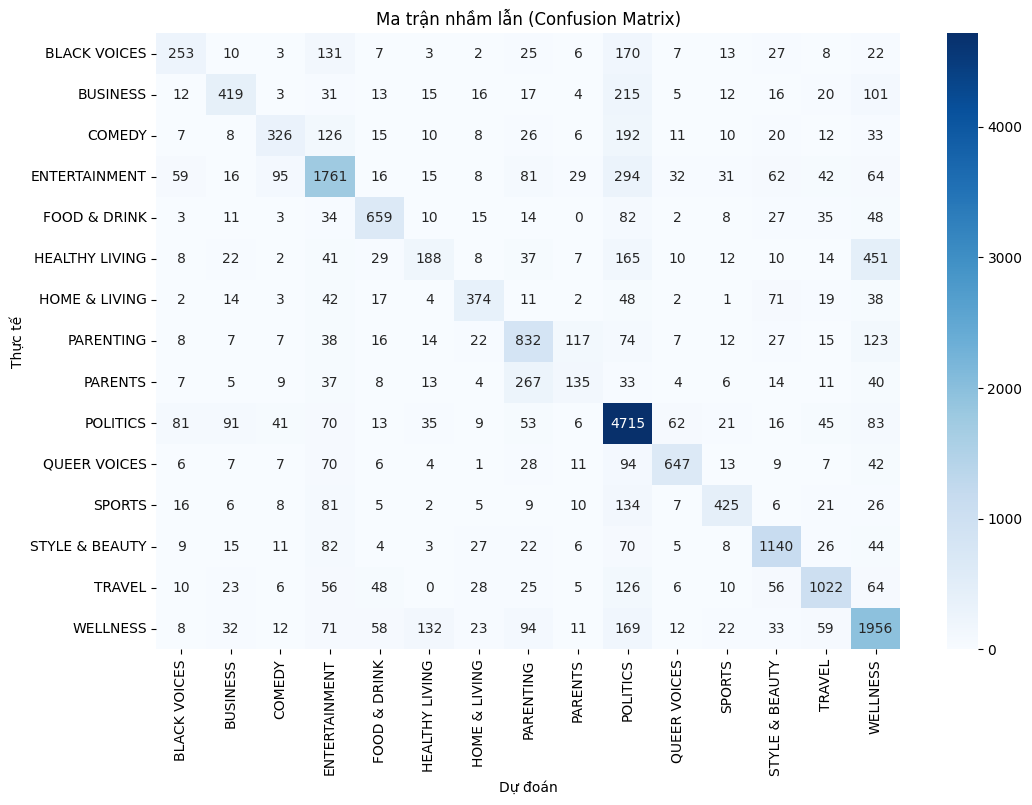

In [ ]:
# 4. Đánh giá & Báo cáo

# Dự đoán trên tập Test
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

# In báo cáo chi tiết
print("\n--- BÁO CÁO KẾT QUẢ TRÊN TẬP TEST ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Vẽ Ma trận nhầm lẫn (Confusion Matrix)
plt.figure(figsize=(12, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_model.classes_,
            yticklabels=best_model.classes_)
plt.title('Ma trận nhầm lẫn (Confusion Matrix)')
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.show()

In [ ]:
import pandas as pd

# Trích xuất kết quả từ RandomizedSearchCV
results_df = pd.DataFrame(random_search.cv_results_)

# Hiển thị top 5 bộ tham số tốt nhất dựa trên rank_test_score
comparision_columns = ['params', 'mean_test_score', 'std_test_score', 'rank_test_score', 'mean_fit_time']
display(results_df[comparision_columns].sort_values('rank_test_score').head())

print(f"\nBộ tham số tốt nhất được chọn: {random_search.best_params_}")
print(f"Độ chính xác trên tập Validation: {random_search.best_score_:.4f}")

,params,mean_test_score,std_test_score,rank_test_score,mean_fit_time
6,"{'tfidf__min_df': 5, 'tfidf__max_features': 30...",0.657710,0.0,1,2610.818427
1,"{'tfidf__min_df': 10, 'tfidf__max_features': 3...",0.653614,0.0,2,2677.367073
0,"{'tfidf__min_df': 10, 'tfidf__max_features': 1...",0.613512,0.0,3,1988.786865
8,"{'tfidf__min_df': 5, 'tfidf__max_features': 10...",0.611441,0.0,4,1959.458464
7,"{'tfidf__min_df': 10, 'tfidf__max_features': 1...",0.603430,0.0,5,999.509225



Bộ tham số tốt nhất được chọn: {'tfidf__min_df': 5, 'tfidf__max_features': 3000, 'clf__n_estimators': 100, 'clf__max_depth': 5, 'clf__learning_rate': 0.2}
Độ chính xác trên tập Validation: 0.6577
